#Worksheet-6

###**Data Understanding and Visualization:**
Download the Provided Data and Complete the following task.

Load and visualize images from a dataset stored in directories, where each subdirectory represents a class. You are expected to write a code:

• Get the list of class directories from the train folder.

• Select one image randomly from each class.

• Display the images in a grid format with two rows using matplotlib.

In [2]:
import os
print(os.listdir('/content'))

['.config', 'FruitinAmazon.zip', 'sample_data']


In [3]:
import zipfile

zip_path = "/content/FruitinAmazon.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content')

In [4]:
print(os.listdir('/content'))

['.config', 'FruitinAmazon', 'FruitinAmazon.zip', 'sample_data']


In [5]:
extract_path = "/content/FruitinAmazon"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("ZIP extracted.")
else:
    print("Dataset already extracted.")

Dataset already extracted.


In [6]:
def find_folder(base_dir, target_name):
    for root, dirs, files in os.walk(base_dir):
        if target_name in dirs:
            return os.path.join(root, target_name)
    return None

train_dir = find_folder(extract_path, "train")
test_dir = find_folder(extract_path, "test")

print("Train folder:", train_dir)
print("Test folder:", test_dir)

Train folder: /content/FruitinAmazon/train
Test folder: /content/FruitinAmazon/test


Image visualization


Classes: ['graviola', 'guarana', 'acai', 'pupunha', 'cupuacu', 'tucuma']


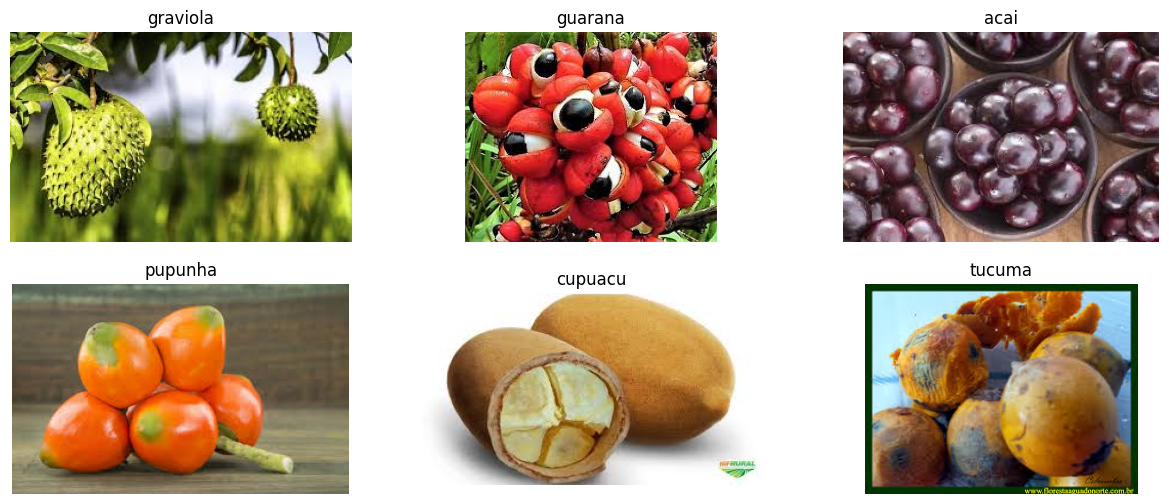

In [7]:
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report

classes = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
print("Classes:", classes)

plt.figure(figsize=(15,6))

for i, cls in enumerate(classes):
    cls_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(cls_path))
    img = Image.open(os.path.join(cls_path, img_name))

    plt.subplot(2, (len(classes)+1)//2, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.show()

**Check for Corrupted Image:**

 Write a script that verifies whether the image in the train directory are valid. If any corrupted images are found, the script must remove the image from the directory and print the message which image have been removed, if none found print ”No Corrupted Images Found.”

• Hint:

-Iterate through each class subdirectory and check if each image is valid.

-Use the Image.open() function to attempt to load each image.

-If the image is corrupted i.e. raises an IOError or SyntaxError, remove the image from the directory and print f"Removed corrupted image: {image_path}".

-Maintain a list of all corrupted image paths for reporting. • Expected Output: No corrupted images found

In [8]:
corrupted_images = []

for cls in classes:
    cls_path = os.path.join(train_dir, cls)
    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        try:
            img = Image.open(img_path)
            img.verify()
        except (IOError, SyntaxError):
            corrupted_images.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if len(corrupted_images) == 0:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


###Check Class Balance:

In [11]:

import os

class_counts = {}

for cls in classes:
    class_path = os.path.join(train_dir, cls)

    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]

        class_counts[cls] = len(images)

print("\nClass Distribution:")
print("="*45)
print(f"{'Class Name':<25}{'Count':>15}")
print("="*45)

for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")

print("="*45)


Class Distribution:
Class Name                         Count
graviola                              15
guarana                               15
acai                                  15
pupunha                               15
cupuacu                               15
tucuma                                15


###Data Generation & Preprocessing

####Create Train & Validation Dataset:

In [14]:
from tensorflow import keras
image_size = (224, 224)
batch_size = 32

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.


###Check Dataset Shape:

In [15]:


for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (32, 224, 224, 3)
Labels shape: (32,)


###Data Augmentation:

In [16]:

data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
]

def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

###Visualize Augmented Images:

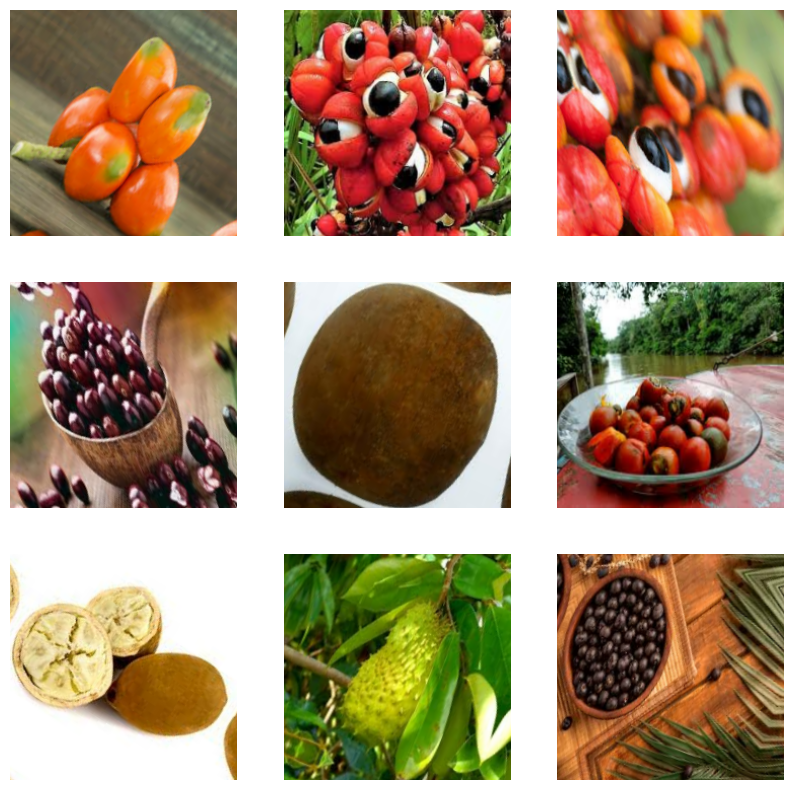

In [17]:

plt.figure(figsize=(10, 10))

for images, _ in train_ds.take(1):
    augmented_images = data_augmentation(images)

    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[i].numpy().astype("uint8"))
        plt.axis("off")

###Build a Deeper CNN Model (Batch Normalization and Dropout):

In [21]:

class_names = train_ds.class_names
model = keras.Sequential([

    layers.Input(shape=(224, 224, 3)),

    # Augmentation + Rescaling
    layers.Lambda(data_augmentation),
    layers.Rescaling(1./255),

    # Block 1
    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Block 4
    layers.Conv2D(256, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Dense Layers
    layers.Flatten(),

    layers.Dense(512),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    layers.Dense(64),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),


    # Output
    layers.Dense(len(class_names), activation='softmax')
])

###Compile Model

In [22]:

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

###Model Summary:

In [23]:

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_1 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             

 Total params: 26,257,670 (100.17 MB)

 Trainable params: 26,254,790 (100.15 MB)

 Non-trainable params: 2,880 (11.25 KB)

###Define Callbacks:

In [24]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        "best_model.keras",
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    )
]

###Train Model:

In [25]:

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.2054 - loss: 2.2156
Epoch 1: val_loss improved from None to 1.76798, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 32s 8s/step - accuracy: 0.1944 - loss: 2.2733 - val_accuracy: 0.1667 - val_loss: 1.7680
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.1800 - loss: 2.3040
Epoch 2: val_loss did not improve from 1.76798
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 5s/step - accuracy: 0.1806 - loss: 2.3127 - val_accuracy: 0.1667 - val_loss: 1.7914
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.1944 - loss: 2.1105
Epoch 3: val_loss did not improve from 1.76798
3/3 ━━━━━━━━━━━━━━━━━━━━ 31s 5s/step - accuracy: 0.2083 - loss: 2.1470 - val_accuracy: 0.1667 - val_loss: 1.7990
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.1644 - loss: 2.2474
Epoch 4: val_loss did not improve from 1.76798
3/3 ━━━━━━━━━━━━━━━━━━━━ 31s 5s/step - accuracy: 0.1806 - loss

###Evaluate model:

In [27]:

loss, acc = model.evaluate(val_ds)
print(f"Validation Accuracy: {acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 758ms/step - accuracy: 0.1667 - loss: 1.7680
Validation Accuracy: 0.1667


#Task 2:
Implement transfer learning using a pre-trained model trained on ImageNet weights, freeze the layers of the model, and fit it only on the output layer to classify the fruits dataset.

Evaluate the model's performance and generate an inference output and classification report.

Did the performance improved compared to training from scratch.

Load Pretrained Model:

In [29]:
from tensorflow.keras.applications import VGG16
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


###Freeze Layers:

In [30]:
for layer in base_model.layers:
    layer.trainable = False

###Add Custom Layers

In [31]:
# Add custom layers on top of the pre-trained model
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)  # Reduces dimensions (height, width) to a single vector per image
x = layers.Dense(1024, activation='relu')(x)    # Fully connected layer with 1024 neurons
outputs = layers.Dense(len(class_names), activation='softmax')(x)   # Output layer for 10 classes (with softmax for multi-class classification)

###Final Model:

In [33]:
from tensorflow.keras.models import Model
model_tl = Model(inputs=base_model.input, outputs=outputs)

###Compile Model:

In [35]:
from tensorflow.keras.optimizers import Adam
model_tl.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


###Train Model

In [36]:

history_tl = model_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    # callbacks=callbacks
)


Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 48s 15s/step - accuracy: 0.2500 - loss: 6.6712 - val_accuracy: 0.2222 - val_loss: 10.2149
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 82s 15s/step - accuracy: 0.4861 - loss: 7.7091 - val_accuracy: 0.1667 - val_loss: 6.0933
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 83s 15s/step - accuracy: 0.8333 - loss: 0.8464 - val_accuracy: 0.3889 - val_loss: 5.2657
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 59s 19s/step - accuracy: 0.9167 - loss: 0.3073 - val_accuracy: 0.4444 - val_loss: 8.3082
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 68s 14s/step - accuracy: 0.8750 - loss: 0.6896 - val_accuracy: 0.3333 - val_loss: 9.3609
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 83s 15s/step - accuracy: 0.9306 - loss: 0.1862 - val_accuracy: 0.3333 - val_loss: 9.0461
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 45s 15s/step - accuracy: 1.0000 - loss: 0.0109 - val_accuracy: 0.3333 - val_loss: 9.2359
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 83s 15s/step - accuracy: 1.0000 - loss: 0.0023 - val_accuracy: 0.3333 - val_loss: 8.8528

###Save Model:

In [37]:
model_tl.save("/content/vgg16_model.keras")

###Evaluate Model:

In [38]:

loss, acc = model_tl.evaluate(val_ds)
print(f"Transfer Learning Accuracy: {acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - accuracy: 0.3889 - loss: 8.2123
Transfer Learning Accuracy: 0.3889


###Predictions:

In [39]:

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model_tl.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

# Convert to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Sample Predictions:", y_pred[:10])
print("Actual Labels:     ", y_true[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Sample Predictions: [4 2 1 5 2 2 1 3 0 3]
Actual Labels:      [4 4 1 5 1 0 1 5 3 0]


###Classification Report:

In [40]:

print("\nClassification Report:\n")

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))



Classification Report:

              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         3
     cupuacu       1.00      0.75      0.86         4
    graviola       0.20      1.00      0.33         1
     guarana       0.00      0.00      0.00         1
     pupunha       1.00      0.25      0.40         4
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.39        18
   macro avg       0.53      0.40      0.36        18
weighted avg       0.73      0.39      0.46        18



In [41]:

print("MODEL PERFORMANCE COMPARISON")

cnn_loss, cnn_acc = model.evaluate(val_ds)
tl_loss, tl_acc = model_tl.evaluate(val_ds)

print(f"CNN from scratch accuracy: {cnn_acc:.4f}")
print(f"VGG16 Transfer Learning accuracy: {tl_acc:.4f}")

if tl_acc > cnn_acc:
    print("\n Transfer Learning performed better")
else:
    print("\n CNN performed better (unusual case due to dataset size)")

MODEL PERFORMANCE COMPARISON
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.1667 - loss: 1.7680
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step - accuracy: 0.3889 - loss: 8.2123
CNN from scratch accuracy: 0.1667
VGG16 Transfer Learning accuracy: 0.3889

 Transfer Learning performed better
